## Loading the Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print('Libraries ready')

Libraries ready


## Load and inspect the data
- check shapes, dtypes and sample rows

In [3]:
df = pd.read_csv('dataset.csv')

In [4]:
#shape and column names
df.shape


(114000, 21)

In [5]:
#column names
df.columns.tolist()

['Unnamed: 0',
 'track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

In [6]:
#first look at rows
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
#data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [8]:
# count the number of missing values as a percentage
(df.isna().sum()/len(df) * 100).sort_values(ascending=False)


artists             0.000877
album_name          0.000877
track_name          0.000877
Unnamed: 0          0.000000
mode                0.000000
time_signature      0.000000
tempo               0.000000
valence             0.000000
liveness            0.000000
instrumentalness    0.000000
acousticness        0.000000
speechiness         0.000000
key                 0.000000
loudness            0.000000
track_id            0.000000
energy              0.000000
danceability        0.000000
explicit            0.000000
duration_ms         0.000000
popularity          0.000000
track_genre         0.000000
dtype: float64

 - artists, album_name, track_name columns contain null values

In [9]:
# duplicate rows
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


## Clean the data
- drop duplicates
- handle nulls
- filter out data with 0 popularity
- convert duration to minutes

In [10]:
#drop duplicates
df= df.drop_duplicates().reset_index(drop=True)

In [11]:
# drop rows with nulls in key columns
cols_to_drop= df.columns[df.columns.isna() <= len(df) * 0.05]
df.dropna(subset=cols_to_drop, inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        113999 non-null  int64  
 1   track_id          113999 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        113999 non-null  int64  
 6   duration_ms       113999 non-null  int64  
 7   explicit          113999 non-null  bool   
 8   danceability      113999 non-null  float64
 9   energy            113999 non-null  float64
 10  key               113999 non-null  int64  
 11  loudness          113999 non-null  float64
 12  mode              113999 non-null  int64  
 13  speechiness       113999 non-null  float64
 14  acousticness      113999 non-null  float64
 15  instrumentalness  113999 non-null  float64
 16  liveness          113999 

In [13]:
# remove rows with zero popularity
df= df[df['popularity'] > 0]
df.shape

(97980, 21)

In [14]:
# duration in minutes
df['duration_min'] = df['duration_ms']/60000
df['duration_min'].head()

0    3.844433
1    2.493500
2    3.513767
3    3.365550
4    3.314217
Name: duration_min, dtype: float64

In [15]:
print(f" Clean dataset : {df.shape[0]:,} rows")

 Clean dataset : 97,980 rows


## Which audio features correlate most with popularity?

In [16]:
audio_features = ['danceability', 'energy', 'loudness', 'key',
                  'speechiness', 'acousticness', 'instrumentalness',
                  'liveness', 'valence', 'tempo', 'popularity']

In [17]:
corr= df[audio_features].corr()

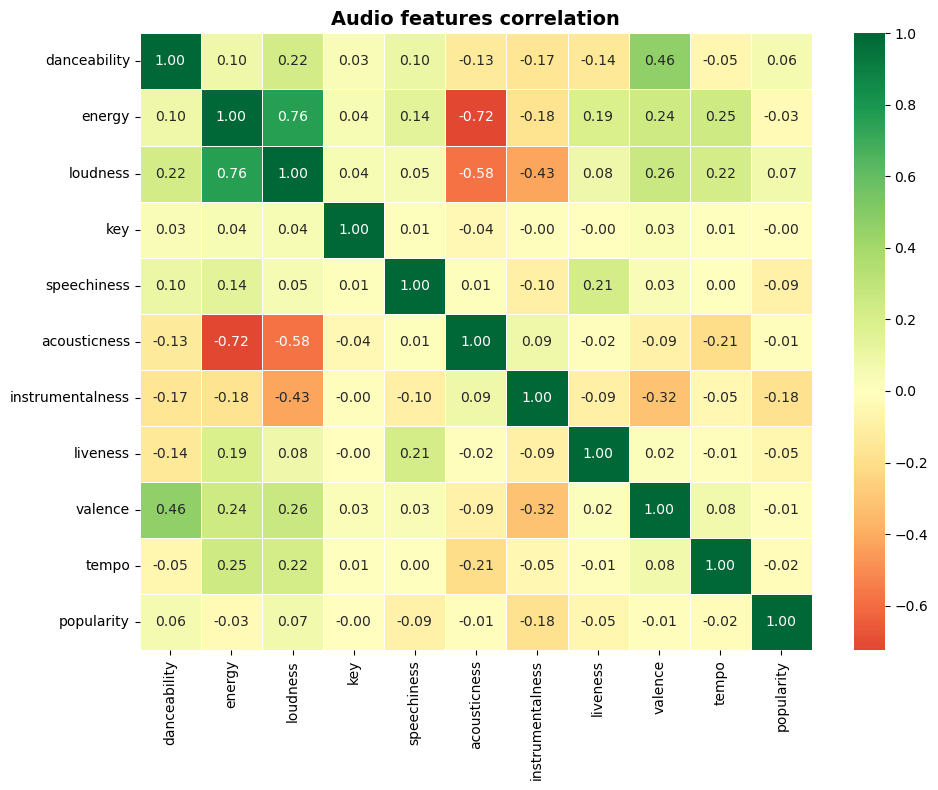

In [18]:
#plotting correlation matrix
fig,ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, annot=True,fmt='.2f',cmap='RdYlGn',center=0, ax=ax, linewidth=0.5)
ax.set_title('Audio features correlation',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

- Danceability and valence are positively correlated
- Danceability and loudness have the strongest positive correlation to popularity
- Instrumentalness has the strongest negatvive correlation to popularity
- Energy and loudness are positively correlated 

## What does the ideal popular track look like?


In [19]:
#comparing high vs low popularity
high_pop=df[df['popularity']>=df['popularity'].quantile(0.75)]
low_pop= df[df['popularity']>=df['popularity'].quantile(0.25)]
features=['danceability', 'energy', 'acousticness', 'valence','loudness','tempo','key']
#high mean
high_mean= high_pop[features].mean()
low_mean= low_pop[features].mean()

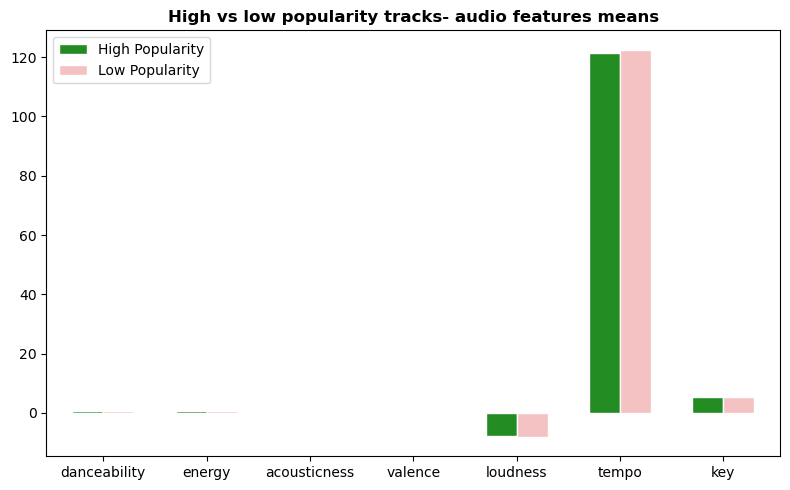

In [20]:
popu= pd.DataFrame({'High Popularity':high_mean, 'Low Popularity': low_mean})
popu.plot(kind='bar',figsize=(8,5),color=['#228B22', '#F4C2C2' ],edgecolor='white',width=0.6)
plt.title('High vs low popularity tracks- audio features means',fontsize=12,fontweight='bold'
         )
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- Tempo contributes highly to whether a track is popular
- Loudness, key, danceability and energy also determine popularity of a track

### Do different music genres have different energy and danceability profiles?

In [23]:
selected_genres =['pop', 'hip-hop', 'rock', 'classical', 'jazz','edm', 'r-n-b', 'country', 'latin', 'metal']
df_genres=df[df['track_genre'].isin(selected_genres)]
#group by energy and danceability
genre_means= df_genres.groupby('track_genre')[['energy','danceability']].mean().reset_index()

# Melt for seaborn
genre_melted = genre_means.melt(id_vars='track_genre',var_name='Feature',value_name='Score')


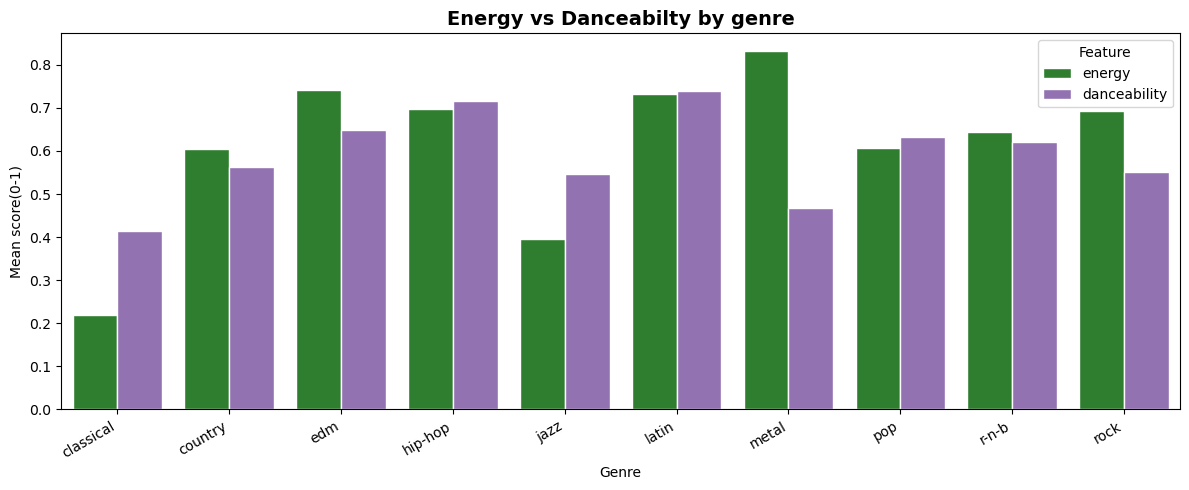

In [30]:
#plotting for seaborn
fig,ax= plt.subplots(figsize=(12,5))
sns.barplot(data=genre_melted, x='track_genre',y='Score',hue='Feature',
             palette={'energy': '#228B22', 'danceability': '#9467BD'},
           edgecolor='white',ax=ax)
ax.set_title('Energy vs Danceabilty by genre',fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Mean score(0-1)')
ax.legend(title='Feature')
plt.xticks(rotation=30,ha='right')
plt.tight_layout()
plt.savefig('genre_profiles.png',dpi=150,bbox_inches='tight')
plt.show()

- metal is the highest in energy, followed by edm and rock
- latin is the highest in danceability followed by hiphop and edm
- Classical is the lowest in energy and danceability
- This shows energy and danceability are related but not the same thing: a metal track can be high-energy but not danceable